In [2]:
import os
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams

#%matplotlib inline

# plot style
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# to prevent ROOT errors
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

#set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"


sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

# -------------------------------
# load processed data (PKL)
# -------------------------------

processed_folder = "/scratch/elena/9Li/results/run1848/processed"
processed_files = sorted(glob(f"{processed_folder}/*.pkl"))

match = re.search(r'run(\d+)', processed_folder)
if match:
    run_number = match.group(1) 
    print(f"Run number: {run_number}")
else:
    run_number = "Not found!"


print(f"Found {len(processed_files)} processed files.")

if len(processed_files) > 0:
    geo_data = functions_bonsai.get_geo_mapping()
    lookup = functions_bonsai.build_lookup_table(geo_data)


    dfs = [pd.read_pickle(f) for f in processed_files]
    df_all = pd.concat(dfs, ignore_index=True)

    print(f"Total clusters loaded: {len(df_all)}")

    # chi2/ndof
    if 'chi2_ndof' in df_all.columns:
        valid_fits = df_all[df_all['fit_success'] == True]
        print(f"Fit success: {len(valid_fits)}")

Welcome to JupyROOT 6.26/04
Run number: 1848
Found 50 processed files.
Total clusters loaded: 15452
Fit success: 15452


In [3]:
# 1. Ensure the lookup is globally accessible to the modules
# We force it into the module's namespace
functions_bonsai.geo = lookup 

if 'df_all' not in locals():
    print("Error: df_all not found.")
else:
    mask_pre = (df_all['fit_success'] == True) & \
               (df_all['time_rms'] < 3.0) & \
               (df_all['vertex_x'].abs() < 270) & \
               (df_all['vertex_y'].abs() < 270)

    df_to_refine = df_all[mask_pre].copy()
    print(f"Candidates for refinement: {len(df_to_refine)}")

    def refine_pipeline(row):
        # We ensure the module sees the lookup table in every iteration
        functions_bonsai.geo = lookup
        
        times = np.array(row['hit_times_ns'])
        mpmt_ids = np.array(row['hit_slot_ids'])
        pmt_ids = np.array(row['hit_channel_ids'])
        v_init = np.array([row['vertex_x'], row['vertex_y'], row['vertex_z']])
        
        try:
            # STAGE 2: dt-cut
            x_p, y_p, z_p, _ = functions_bonsai.getxyz(lookup, mpmt_ids, pmt_ids)
            pmt_pos = np.column_stack([x_p, y_p, z_p])
            
            c_n = 29.9792458 / 1.33 
            tof = np.linalg.norm(pmt_pos - v_init, axis=1) / c_n
            
            t_corr = times - tof
            t0_guess = np.median(t_corr)
            dt = t_corr - t0_guess
            
            clean_mask = (np.abs(dt) < 3.0)
            
            if np.sum(clean_mask) < 6:
                return pd.Series([np.nan]*5, index=['v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'])

            # STAGE 3: fine adjustment
            vertex = functions_multilateration.run_multilateration_candidate(
                times[clean_mask], mpmt_ids[clean_mask], pmt_ids[clean_mask],
                sigma_t=2.2,
                guess=(v_init[0], v_init[1], v_init[2], t0_guess)
            )
            
            if vertex["success"]:
                # vertex["pulls"] are (dt / sigma_t). To get RMS in ns, multiply by sigma_t (2.2)
                t_rms_final = np.std(vertex["pulls"] * 2.2)
                return pd.Series([vertex['x'], vertex['y'], vertex['z'], t_rms_final, np.sum(clean_mask)], 
                                 index=['v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'])
        except:
            pass
        
        return pd.Series([np.nan]*5, index=['v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'])

    print("Processing refinement...")
    # Apply and join
    refined_results = df_to_refine.apply(refine_pipeline, axis=1)
    df_final = pd.concat([df_to_refine, refined_results], axis=1)
    
    # Check data
    valid_count = df_final['t_rms_fine'].notna().sum()
    print(f"Refinement completed. Valid results: {valid_count} / {len(df_to_refine)}")

Candidates for refinement: 151184
Processing refinement...
Refinement completed. Valid results: 149987 / 151184


In [4]:
print("Columns in df_final:", df_final.columns.tolist())
print(f"Total rows: {len(df_final)}")

Columns in df_final: ['t_window_start_ns', 't_window_start_rel_ns', 'nHits', 'spill_id', 'nCLusters_in_spill', 'hit_card_ids', 'hit_slot_ids', 'hit_channel_ids', 'hit_position_ids', 'hit_times_ns', 'hit_charges', 'vertex_x', 'vertex_y', 'vertex_z', 'fit_success', 'n_hits_used', 'time_rms', 'chi2', 'ndof', 'chi2_ndof', 'v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine']
Total rows: 151184


In [5]:
df_final.head()

,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,nCLusters_in_spill,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,...,n_hits_used,time_rms,chi2,ndof,chi2_ndof,v_x_fine,v_y_fine,v_z_fine,t_rms_fine,nhits_fine
0,1.600714e+10,85972.235668,25,0,936,"[16, 21, 21, 98, 47, 99, 99, 19, 1, 27, 11, 46...","[73, 64, 64, 100, 13, 90, 90, 41, 70, 2, 10, 4...","[3, 5, 15, 11, 16, 5, 8, 2, 7, 0, 8, 9, 2, 9, ...","[18, 7, 5, 11, 14, 7, 9, 0, 2, 17, 9, 3, 0, 3,...","[16007144267.85772, 16007144256.741348, 160071...",...,25,1.673320,71.227766,21.0,3.391798,-126.034662,21.757692,-61.612664,1.063072,23.0
1,1.600719e+10,129169.427015,71,0,936,"[32, 23, 16, 16, 16, 15, 15, 15, 103, 98, 93, ...","[75, 47, 73, 73, 73, 58, 58, 58, 98, 100, 101,...","[17, 3, 1, 17, 14, 9, 12, 15, 1, 2, 2, 6, 7, 1...","[15, 18, 6, 15, 13, 3, 4, 5, 6, 0, 0, 8, 2, 11...","[16007187459.59153, 16007187464.494902, 160071...",...,70,2.469820,437.916654,66.0,6.635101,-64.344239,-37.264296,-294.123861,1.255537,64.0
3,1.600731e+10,256269.252436,18,0,936,"[42, 23, 23, 20, 71, 3, 3, 7, 91, 45, 117, 105...","[80, 47, 47, 81, 103, 68, 68, 34, 94, 21, 5, 3...","[15, 8, 18, 9, 4, 7, 15, 12, 5, 15, 16, 4, 9, ...","[5, 9, 16, 3, 1, 2, 5, 4, 7, 5, 14, 1, 3, -2, ...","[16007314562.642288, 16007314558.071325, 16007...",...,13,1.361766,24.294064,9.0,2.699340,-121.667753,-190.136790,31.892447,1.016334,12.0
4,1.600736e+10,302322.478849,35,0,936,"[25, 25, 25, 20, 93, 89, 99, 71, 38, 87, 87, 1...","[62, 62, 62, 81, 101, 89, 90, 103, 65, 88, 88,...","[0, 2, 4, 3, 0, 11, 5, 2, 3, 2, 8, 6, 3, 17, 4...","[17, 0, 1, 18, 17, 11, 7, 0, 18, 0, 9, 8, 18, ...","[16007360608.53276, 16007360607.798445, 160073...",...,35,1.144621,45.858703,31.0,1.479313,-37.114375,37.235991,-119.951770,1.144069,35.0
5,1.600747e+10,416665.358004,78,0,936,"[42, 42, 42, 42, 23, 23, 23, 23, 23, 23, 23, 2...","[80, 80, 80, 80, 47, 47, 47, 47, 47, 47, 47, 4...","[0, 1, 3, 4, 2, 4, 7, 9, 10, 11, 13, 16, 8, 1,...","[17, 6, 18, 1, 0, 1, 2, 3, 10, 11, 12, 14, 9, ...","[16007474952.73472, 16007474953.317741, 160074...",...,78,2.078026,342.474827,74.0,4.628038,-112.576685,-23.928008,-93.410414,0.993964,73.0


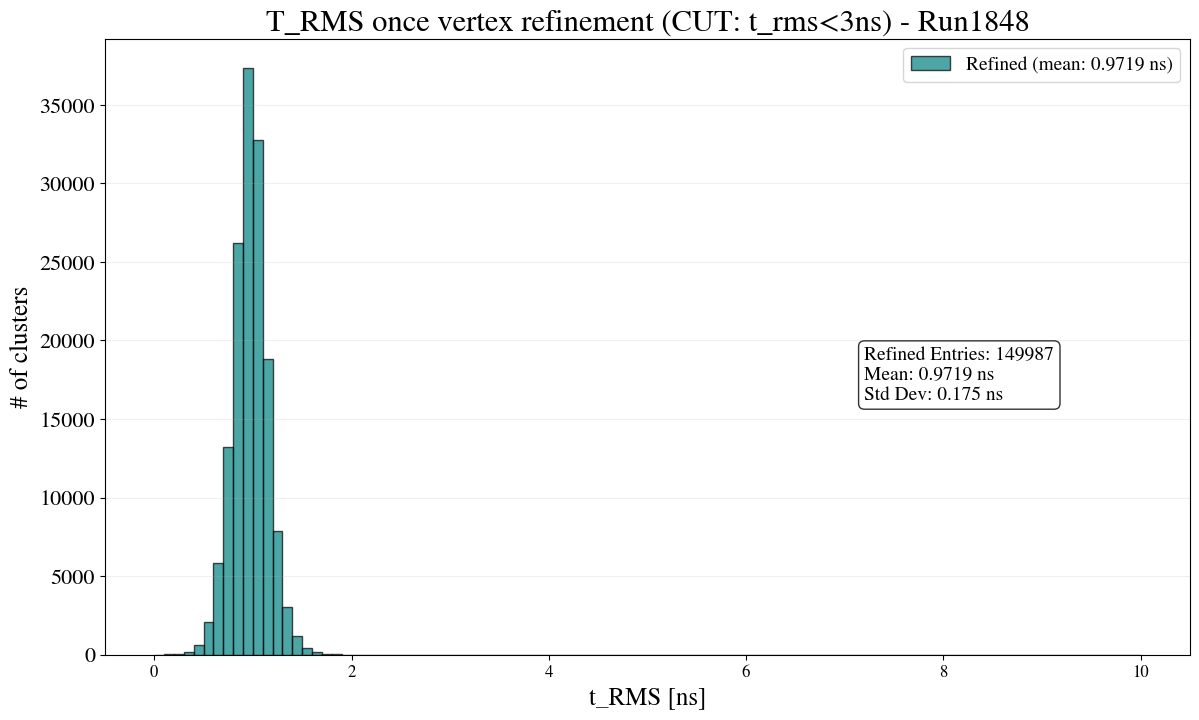

Final refined Mean T_RMS: 0.9719 ns


In [6]:
#Select only the successfully refined clusters
df_plot = df_final[df_final['t_rms_fine'].notna()].copy()

if len(df_plot) == 0:
    print("Zero valid results. Check if the 'guess' or 'clean_mask' logic is too strict.")
else:
    plt.figure(figsize=(14, 8))

    #m1, std1 = df_plot['time_rms'].mean(), df_plot['time_rms'].std()
    m2, std2 = df_plot['t_rms_fine'].mean(), df_plot['t_rms_fine'].std()

    plt.hist(df_plot['t_rms_fine'], bins=100, alpha=0.7, range=[0,10],
             color='teal', label=f'Refined (mean: {m2:.4f} ns)', edgecolor='black')

    plt.title(f"T_RMS once vertex refinement (CUT: t_rms<3ns) - Run{run_number}", fontsize=22)
    plt.xlabel("t_RMS [ns]", fontsize=18)
    plt.ylabel("# of clusters", fontsize=18)
    

    stats_text = (f"Refined Entries: {len(df_plot)}\n"
                  f"Mean: {m2:.4f} ns\n"
                  f"Std Dev: {std2:.3f} ns")
    plt.text(0.7, 0.5, stats_text, transform=plt.gca().transAxes, fontsize=14,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend(loc='upper right', fontsize=14)
    plt.grid(axis='y', alpha=0.2)
    plt.show()

    print(f"Final refined Mean T_RMS: {m2:.4f} ns")

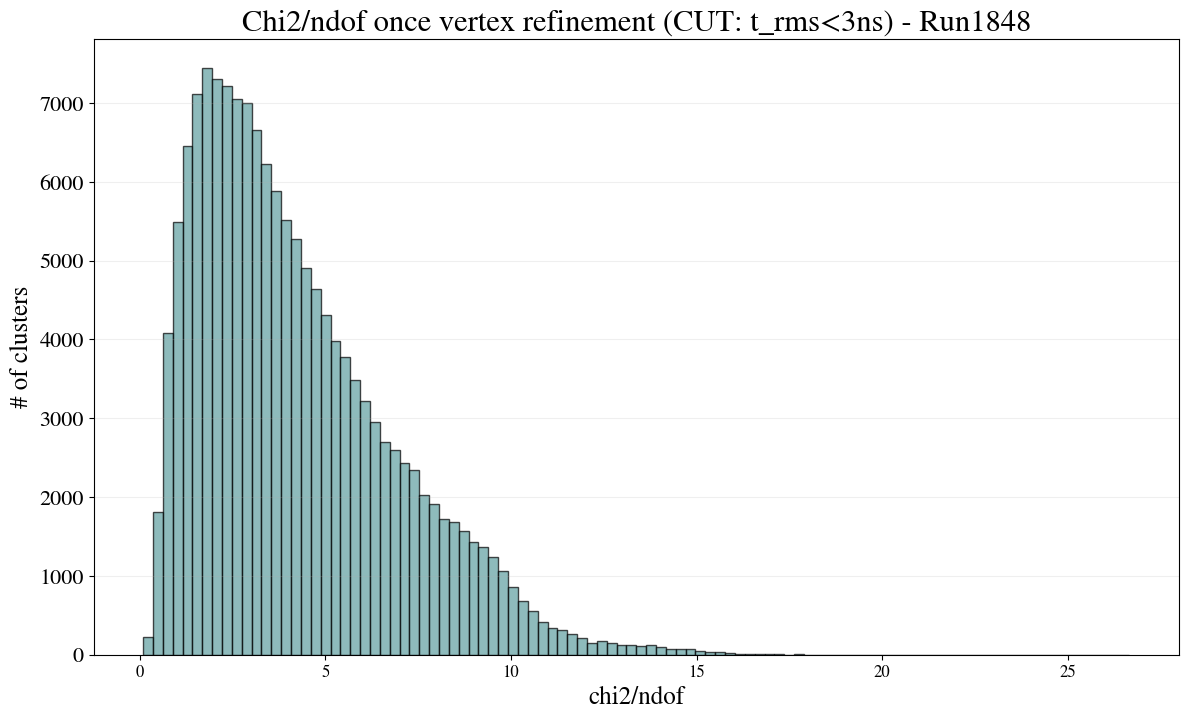

In [7]:
#Select only the successfully refined clusters
df_plot = df_final[df_final['chi2_ndof'].notna()].copy()

if len(df_plot) == 0:
    print("Zero valid results. Check if the 'guess' or 'clean_mask' logic is too strict.")
else:
    plt.figure(figsize=(14, 8))

    plt.hist(df_plot['chi2_ndof'], bins=100, alpha=0.7, color='cadetblue', edgecolor='black')

    plt.title(f"Chi2/ndof once vertex refinement (CUT: t_rms<3ns) - Run{run_number}", fontsize=22)
    plt.xlabel("chi2/ndof", fontsize=18)
    plt.ylabel("# of clusters", fontsize=18)

    plt.grid(axis='y', alpha=0.2)
    plt.show()

In [16]:
import matplotlib.patches as patches

mask_refined = (df_final['v_x_fine'].notna()) & \
               (df_final["chi2_ndof"] < 5) 

df_clean = df_final[mask_refined].copy()



fig, axs = plt.subplots(1, 3, figsize=(24, 7))
beam_pipe = [0.0, -42.47, -138.79] 

#FV
x_lims = [-20, 20]
y_lims = [-62, -22]
z_lims = [-160, -60]

box_style = dict(linewidth=2, edgecolor='red', facecolor='none', linestyle='--')

# XY plane
im0 = axs[0].hist2d(df_clean['v_x_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)
rect_xy = patches.Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], **box_style, label='Fiducial Volume')
axs[0].add_patch(rect_xy)
axs[0].set_title("XY plane")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
axs[0].legend(loc='upper right', fontsize=12)
plt.colorbar(im0[3], ax=axs[0], label='Counts')

# ZX plane
im1 = axs[1].hist2d(df_clean['v_z_fine'], df_clean['v_x_fine'], bins=70, cmap='cividis', cmin=1)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)
rect_zx = patches.Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], **box_style)
axs[1].add_patch(rect_zx)
axs[1].set_title("ZX plane (from the top)")
axs[1].set_xlabel("vertex z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')

# ZY plane
im2 = axs[2].hist2d(df_clean['v_z_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)
rect_zy = patches.Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], **box_style)
axs[2].add_patch(rect_zy)
axs[2].set_title("ZY plane")
axs[2].set_xlabel("vertex z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')

plt.suptitle(f"Refined spatial distribution (T_RMS < 3ns + chi2_ndof < 5) - Run{run_number}", fontsize=24)
plt.tight_layout()
plt.show()



total_events = len(df_all)
passed_events = len(df_clean)
percentage = (passed_events / total_events) * 100


print(f"Total clusters analyzed:           {total_events}")
print(f"Events satisfying mask (refined):  {passed_events}")
print(f"Selection efficiency:              {percentage:.2f}%")


NameError: name 'df_final' is not defined

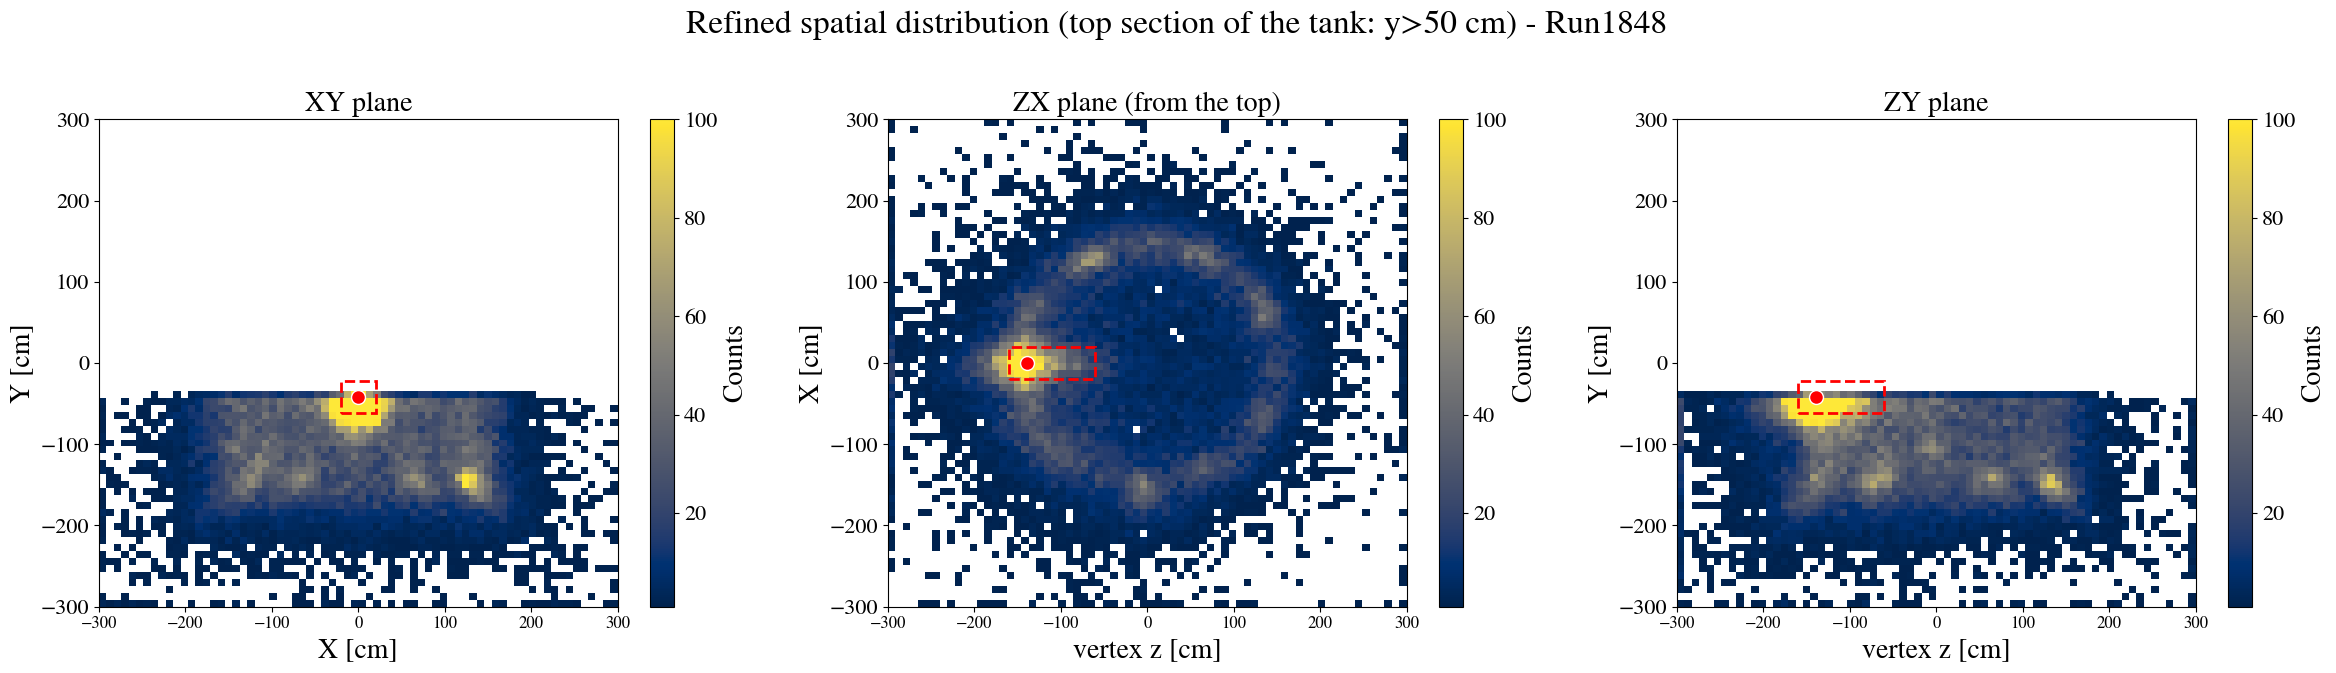

In [9]:
tank_limit = 300 

mask_refined = (df_final['fit_success'] == True) & \
               (df_final["chi2_ndof"] < 5) & \
               (df_final["v_y_fine"] < -40) 

df_clean = df_final[mask_refined].copy()

fig, axs = plt.subplots(1, 3, figsize=(24, 7))
beam_pipe = [0.0, -42.47, -138.79] 
x_lims, y_lims, z_lims = [-20, 20], [-62, -22], [-160, -60]
box_style = dict(linewidth=2, edgecolor='red', facecolor='none', linestyle='--')

#fix color bar for comparison
VMAX_DENSITY = 100 

# XY plane 
im0 = axs[0].hist2d(df_clean['v_x_fine'], df_clean['v_y_fine'], 
                    bins=70, cmap='cividis', cmin=1, 
                    range=[[-tank_limit, tank_limit], [-tank_limit, tank_limit]],
                    vmax=VMAX_DENSITY)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)
axs[0].add_patch(patches.Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], **box_style, label='Fiducial Volume'))
axs[0].set_title("XY plane")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
plt.colorbar(im0[3], ax=axs[0], label='Counts')

# ZX plane
im1 = axs[1].hist2d(df_clean['v_z_fine'], df_clean['v_x_fine'], 
                    bins=70, cmap='cividis', cmin=1,
                    range=[[-tank_limit, tank_limit], [-tank_limit, tank_limit]],
                    vmax=VMAX_DENSITY)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)
axs[1].add_patch(patches.Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], **box_style))
axs[1].set_title("ZX plane (from the top)")
axs[1].set_xlabel("vertex z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')

# ZY plane 
im2 = axs[2].hist2d(df_clean['v_z_fine'], df_clean['v_y_fine'], 
                    bins=70, cmap='cividis', cmin=1,
                    range=[[-tank_limit, tank_limit], [-tank_limit, tank_limit]],
                    vmax=VMAX_DENSITY)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)
axs[2].add_patch(patches.Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], **box_style))
axs[2].set_title("ZY plane")
axs[2].set_xlabel("vertex z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')

# force tank limits
for ax in axs:
    ax.set_xlim(-tank_limit, tank_limit)
    ax.set_ylim(-tank_limit, tank_limit)

plt.suptitle(f"Refined spatial distribution (top section of the tank: y>50 cm) - Run{run_number}", fontsize=24)
plt.tight_layout()
plt.show()

In [10]:
fv_mask = (df_final['fit_success'] == True) & \
          (df_final['v_x_fine'] >= x_lims[0]) & (df_final['v_x_fine'] <= x_lims[1]) & \
          (df_final['v_y_fine'] >= y_lims[0]) & (df_final['v_y_fine'] <= y_lims[1]) & \
          (df_final['v_z_fine'] >= z_lims[0]) & (df_final['v_z_fine'] <= z_lims[1]) & \
          (df_final["chi2_ndof"] < 5)

df_fv = df_final[fv_mask].copy()
df_fv['t_ms'] = df_fv['t_window_start_rel_ns'] / 1e6

print(f"Total candidates in fiducial volume: {len(df_fv)}")

Total candidates in fiducial volume: 3077


# WE SAVE THE FILTERED CLUSTER CANDIDATES!

In [11]:
output_dir = "/scratch/elena/9Li/results/filtered_cluster_candidates"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

filename = f"{output_dir}/df_fv_run{run_number}_n{len(df_fv)}.pkl"

df_fv['run_number'] = run_number  
df_fv.to_pickle(filename)

print(f"Run {run_number} save!")
print(f"File name: {filename}")
print(f"Filtered number of cluster candidates saved: {len(df_fv)}")

Run 1848 save!
File name: /scratch/elena/9Li/results/filtered_cluster_candidates/df_fv_run1848_n3077.pkl
Filtered number of cluster candidates saved: 3077


# high statistics!

In [11]:
import glob
from scipy.optimize import curve_fit

pattern = '/scratch/elena/9Li/results/filtered_cluster_candidates/df_fv_run1*.pkl'
all_files = glob.glob(pattern)
all_files.sort()

if not all_files:
    raise FileNotFoundError(f"No files found matching: {pattern}")

print(f"Found {len(all_files)} files. Loading...")
df_list = [pd.read_pickle(f) for f in all_files]
df_combined = pd.concat(df_list, ignore_index=True)


time_col = 't_ms' 

print(f"Using column '{time_col}' for time distribution.")
print(f"Total candidates combined: {len(df_combined)}")

Found 2 files. Loading...
Using column 't_ms' for time distribution.
Total candidates combined: 2333


Histogram of 25 bins, 20 ms width.


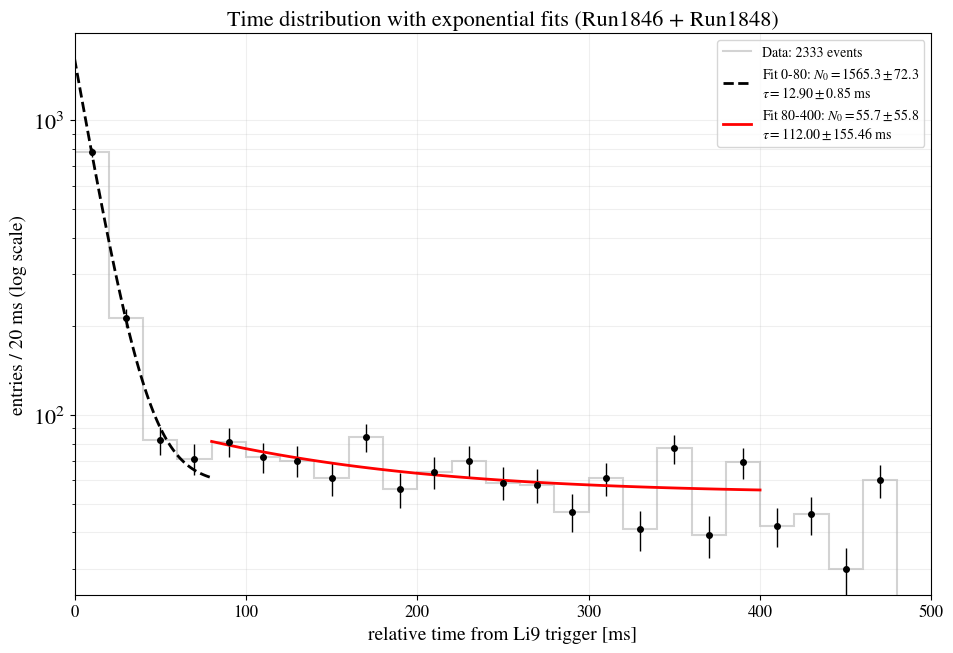

Fit in 0-80ms range:   N0 = 1565.306 +/- 72.264, tau = 12.904 +/- 0.848 ms
Fit in 80-400ms range:  N0 = 55.667 +/- 55.771, tau = 112.004 +/- 155.463 ms


In [17]:
bin_width = 20 #ms 
bins = np.arange(0, 500 + bin_width, bin_width)


counts, bin_edges = np.histogram(df_combined[time_col], bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


errors = np.sqrt(np.maximum(counts, 1))

print(f"Histogram of {len(counts)} bins, {bin_width} ms width.")

def expo_func(t, n0, tau, c):
    return n0 * np.exp(-t / tau) + c

mask_1 = (bin_centers >= 0) & (bin_centers <= 80)
mask_2 = (bin_centers >= 80) & (bin_centers <= 400)


#range: 0-80 ms
popt1, pcov1 = curve_fit(expo_func, bin_centers[mask_1], counts[mask_1], p0=[max(counts), 15, 1])
n0_1, tau1, c1 = popt1
e_n0_1 = np.sqrt(pcov1[0,0])
e_tau1 = np.sqrt(pcov1[1,1])

#range:80-400 ms
popt2, pcov2 = curve_fit(expo_func, bin_centers[mask_2], counts[mask_2], p0=[counts[mask_2][0], 100, 1])
n0_2, tau2, c2 = popt2
e_n0_2 = np.sqrt(pcov2[0,0])
e_tau2 = np.sqrt(pcov2[1,1])



plt.figure(figsize=(10, 7))

plt.stairs(counts, bin_edges, color='lightgray', linewidth=1.5, label=f'Data: {int(sum(counts))} events')
plt.errorbar(bin_centers, counts, yerr=errors, fmt='o', color='black', markersize=4, capsize=0, elinewidth=1, ls='none')

#(0-80 ms)
t_fit1 = np.linspace(0, 80, 100)
label1 = (rf'Fit 0-80: $N_0 = {n0_1:.1f} \pm {e_n0_1:.1f}$' + '\n' +
          rf'$\tau = {tau1:.2f} \pm {e_tau1:.2f}$ ms')
plt.plot(t_fit1, expo_func(t_fit1, *popt1), color='black',linestyle="--", linewidth=2, label=label1)

#(80-400 ms)
t_fit2 = np.linspace(80, 400, 100)
label2 = (rf'Fit 80-400: $N_0 = {n0_2:.1f} \pm {e_n0_2:.1f}$' + '\n' +
          rf'$\tau = {tau2:.2f} \pm {e_tau2:.2f}$ ms')
plt.plot(t_fit2, expo_func(t_fit2, *popt2), color='red', linewidth=2, label=label2)


plt.title('Time distribution with exponential fits (Run1846 + Run1848)', fontsize=16)
plt.xlabel('relative time from Li9 trigger [ms]', fontsize=14)
plt.ylabel(f'entries / {bin_width} ms (log scale)', fontsize=14)
plt.grid(True, which='both', linestyle='-', alpha=0.2)
plt.yscale("log")
plt.xlim(0, 500)
plt.ylim(bottom=max(1, plt.ylim()[0])) 

plt.legend(loc='upper right', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


print(f"Fit in 0-80ms range:   N0 = {n0_1:.3f} +/- {e_n0_1:.3f}, tau = {tau1:.3f} +/- {e_tau1:.3f} ms")
print(f"Fit in 80-400ms range:  N0 = {n0_2:.3f} +/- {e_n0_2:.3f}, tau = {tau2:.3f} +/- {e_tau2:.3f} ms")